In [1]:
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import Model

In [2]:
X = np.load("../data/landmarks/X_1000.npy")
y = np.load("../data/landmarks/y_1000.npy")

print(X.shape)
print(y.shape)

(1000, 64, 63)
(1000,)


In [3]:
num_classes = len(np.unique(y))

print(num_classes)

99


In [4]:
class PositionalEmbedding(layers.Layer):

    def __init__(self,sequence_length,embed_dim):
        super().__init__()

        self.position_embeddings = (
                layers.Embedding(
                input_dim=sequence_length,
                output_dim=embed_dim
            )
        )

        self.sequence_length = sequence_length

    def call(self, x):

        positions = tf.range(
            start=0,
            limit=self.sequence_length,
            delta=1
        )

        embedded_positions = (
            self.position_embeddings(
                positions
            )
        )

        return x + embedded_positions

In [5]:
class TransformerBlock(layers.Layer):

    def __init__(self,embed_dim,num_heads,ff_dim,rate=0.1):
        super().__init__()

        self.att = (layers.MultiHeadAttention(num_heads=num_heads,key_dim=embed_dim))

        self.ffn = tf.keras.Sequential([
            layers.Dense(
                ff_dim,
                activation="gelu"
            ),
            layers.Dense(embed_dim)
        ])

        self.norm1 = (layers.LayerNormalization())
        self.norm2 = (layers.LayerNormalization())

        self.drop1 = (layers.Dropout(rate))

        self.drop2 = (layers.Dropout(rate))

    def call(self,inputs,training=False):

        attn_output = self.att(inputs,inputs)
        attn_output = self.drop1(attn_output,training=training)

        out1 = self.norm1(inputs + attn_output)

        ffn_output = self.ffn(out1)

        ffn_output = self.drop2(ffn_output,training=training)

        return self.norm2(out1 + ffn_output)

In [6]:
def build_model(num_classes):

    inputs = tf.keras.Input(shape=(64,63))

    x = layers.Dense(256)(inputs)
    x = PositionalEmbedding(64,256)(x)
    x = TransformerBlock(embed_dim=256,num_heads=8,ff_dim=512)(x)
    x = TransformerBlock(embed_dim=256,num_heads=8,ff_dim=512)(x)
    x = TransformerBlock(embed_dim=256,num_heads=8,ff_dim=512)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256,activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(num_classes,activation="softmax")(x)

    return Model(inputs,outputs)

In [7]:
model = build_model(num_classes)
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 63)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64, 256)        │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 64, 256)        │        16,384 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 64, 256)        │     2,367,488 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 64, 256)        │     2,367,488 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 64, 256)        │     2,367,488 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 99)             │        25,443 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,226,467 (27.57 MB)

 Trainable params: 7,226,467 (27.57 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print(np.unique(y))

[   8   31   48   81  154  164  168  191  193  196  204  210  222  247
  260  280  285  313  317  323  347  358  371  392  416  418  422  433
  435  462  466  472  477  546  548  568  596  626  678  703  705  709
  732  754  784  789  802  840  849  858  884  888  950  977  987  990
  994 1016 1026 1060 1063 1077 1078 1118 1147 1166 1178 1212 1229 1232
 1284 1286 1291 1374 1379 1465 1497 1509 1523 1553 1559 1634 1704 1744
 1751 1764 1782 1797 1813 1913 1917 1946 1954 1955 1972 1977 1990 1991
 1993]


In [9]:
unique_labels = np.unique(y)

label_map = { old: new for new, old in enumerate(unique_labels) }

y = np.array( [label_map[label] for label in y] )

In [10]:
print(np.unique(y))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98]


In [11]:
num_classes = len(np.unique(y))

print(num_classes)

99


In [14]:
print(y.min())
print(y.max())
print(len(np.unique(y)))

unique, counts = np.unique(y, return_counts=True)

print("Min samples:", counts.min())
print("Max samples:", counts.max())
print("Mean samples:", counts.mean())

print("X mean:", X.mean())
print("X std:", X.std())
print("X min:", X.min())
print("X max:", X.max())

0
98
99
Min samples: 5
Max samples: 16
Mean samples: 10.1010101010101
X mean: 0.22313097
X std: 0.2833278
X min: -0.16800056
X max: 1.1328378


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
mean = X_train.mean()
std = X_train.std()

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std

print(X_train.mean())
print(X_train.std()) 

In [47]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
    
history = model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=30,batch_size=32,callbacks=[early_stopping])

Epoch 1/30


25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 565ms/step - accuracy: 0.0100 - loss: 4.8664 - val_accuracy: 0.0100 - val_loss: 4.6591
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 520ms/step - accuracy: 0.0188 - loss: 4.6632 - val_accuracy: 0.0050 - val_loss: 4.6229
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 521ms/step - accuracy: 0.0113 - loss: 4.6243 - val_accuracy: 0.0050 - val_loss: 4.6091
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 519ms/step - accuracy: 0.0137 - loss: 4.6067 - val_accuracy: 0.0050 - val_loss: 4.6132
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 519ms/step - accuracy: 0.0113 - loss: 4.6014 - val_accuracy: 0.0100 - val_loss: 4.6124
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 547ms/step - accuracy: 0.0137 - loss: 4.6002 - val_accuracy: 0.0150 - val_loss: 4.6041
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 563ms/step - accuracy: 0.0113 - loss: 4.5964 - val_accuracy: 0.0100 - val_loss: 4.6071
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 545ms/step - accuracy: 0.0150 - loss: 4.5916 - val_accuracy: 0.005

In [48]:
display(history.history.keys())
display(history.history["accuracy"][-1])
display(history.history["val_accuracy"][-1])

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

0.01875000074505806

0.004999999888241291

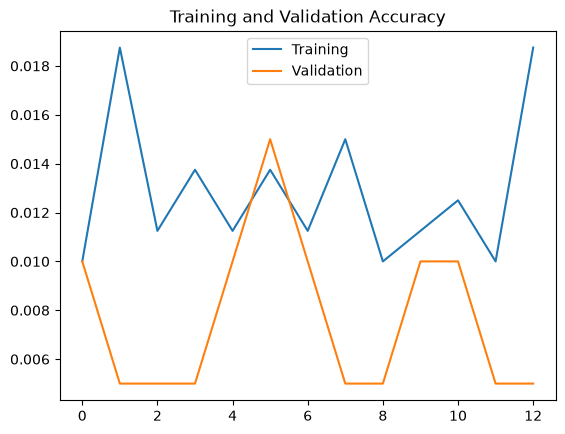

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"],label="train_accuracy")
plt.plot(history.history["val_accuracy"],label="val_accuracy")
plt.title("Training and Validation Accuracy")
plt.legend(["Training", "Validation"])
plt.show()

In [ ]:
unique,counts = np.unique(y,return_counts=True)
print("Classes:", len(unique))
print("Min samples:", counts.min())
print("Max samples:", counts.max())
print("Mean samples:", counts.mean())